<a href="https://colab.research.google.com/github/tuhaovan917-ship-it/thuc_hanh_deeplearning/blob/main/buoi_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Khảo sát và load dataset

In [22]:
import pandas as pd

url = "https://github.com/huynhhoc/DataAnalystDeepLearning/raw/refs/heads/main/Data/tripadvisor.csv"

# 1. Đọc dữ liệu: Thêm header=0 để báo Python bỏ qua dòng tiêu đề gốc của file CSV, tránh bị lệch dữ liệu
df = pd.read_csv(url, names=['User_Profile', 'Rating', 'Review_Text'], usecols=[0, 1, 2], header=0)

# 2. Hiển thị dữ liệu đầu tiên (Dùng print để không bị các lệnh dưới đè mất)
print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
print(df.head())
print("\n" + "="*50 + "\n")

# 3. Kiểm tra tổng quan cấu trúc file
print("--- THÔNG TIN TỔNG QUAN DATASET ---")
df.info()
print("\n" + "="*50 + "\n")

# 4. Đếm số lượng giá trị thiếu ban đầu
print("--- SỐ LƯỢNG GIÁ TRỊ THIẾU BAN ĐẦU ---")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# 5. Tiến hành lọc bỏ các dòng trống
df_clean = df.dropna(subset=['Review_Text', 'Rating']).copy()

# 6. Kiểm tra lại xem dữ liệu đã thực sự sạch chưa
print("--- KIỂM TRA LẠI SAU KHI LỌC SẠCH ---")
print(df_clean.isnull().sum())
print("\nSố lượng dòng còn lại sau khi lọc sạch:", df_clean.shape[0])

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---
                 User_Profile     Rating  \
0  /Profile/F4416DUstephaniet  bubble_50   
1         /Profile/447ximenaa  bubble_50   
2              /Profile/P2H72  bubble_40   
3            /Profile/anneroe  bubble_50   
4         /Profile/Flyuphidog  bubble_50   

                                         Review_Text  
0  All staff is helpful and pleasant! Today I was...  
1                                                  …  
2                                                  …  
3  We went to the included Aqua Zumba class and l...  
4                                                NaN  


--- THÔNG TIN TỔNG QUAN DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18875 entries, 0 to 18874
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User_Profile  18874 non-null  object
 1   Rating        18874 non-null  object
 2   Review_Text   9879 non-null   object
dtypes: object(3)

# Tiền xử lý dữ liệu

## Chuẩn hóa nhãn dữ liệu

In [27]:
import re

def clean_text(text):
    # 1. Chuyển toàn bộ thành chữ thường
    text = str(text).lower()

    # 2. Xóa các ký tự đặc biệt, ký tự lạ và dấu câu (chỉ giữ lại chữ cái từ a-z và khoảng trắng)
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Xóa các khoảng trắng thừa ở đầu, cuối và giữa các từ
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Áp dụng hàm làm sạch lên toàn bộ cột Review_Text trước khi chia tập dữ liệu
df_clean['Review_Text_Cleaned'] = df_clean['Review_Text'].apply(clean_text)

# Hiển thị thử để so sánh văn bản trước và sau khi dọn dẹp
df_clean[['Review_Text', 'Review_Text_Cleaned']].head()

,Review_Text,Review_Text_Cleaned
0,All staff is helpful and pleasant! Today I was...,all staff is helpful and pleasant today i was ...
1,…,
2,…,
3,We went to the included Aqua Zumba class and l...,we went to the included aqua zumba class and l...
9,Love the music and atmosphere outside by the b...,love the music and atmosphere outside by the b...


In [28]:
# Tạo một hàm để định nghĩa quy luật chuyển đổi sắc thái cảm xúc
# Đầu vào là chuỗi 'bubble_xx', đầu ra là 1 hoặc 0
def convert_rating_to_sentiment(rating_string):
  # nếu ra ting là bubble_50 hoặc bubble_40 thì coi là tích cực (1)
  if rating_string in ['bubble_50', 'bubble_40']:
    return 1
  else:
    return 0

# Áp dụng hàm trên vào cột 'Rating' để tạo ra một cột mới với tên 'Sentiment'
df_clean['Sentiment'] = df_clean['Rating'].apply(convert_rating_to_sentiment)

# HKiểm tra kết quả bằng cách hiển thị vài dòng xem cột mới đã được chuyển hóa đúng chưa
df_clean[['Rating', 'Sentiment']].head(1000)

,Rating,Sentiment
0,bubble_50,1
1,bubble_50,1
2,bubble_40,1
3,bubble_50,1
9,bubble_50,1
...,...,...
1905,bubble_50,1
1906,bubble_50,1
1907,bubble_50,1
1908,bubble_50,1


## Tách dữ liệu chia thành tập train, val và test

In [29]:
from sklearn.model_selection import train_test_split

# Thay đổi nguồn dữ liệu sang df_clean đã được lọc sạch dữ liệu trống
X = df_clean['Review_Text_Cleaned']
y = df_clean['Sentiment']

# Bước 1: Tách thành Train (70%) và tập Tạm thời (30%)
X_train, X_temporary, y_train, y_temporary = train_test_split(X, y, test_size=0.3, random_state=42)

# Bước 2: Tách tập Tạm thời thành Val (20% tổng) và Test (10% tổng)
X_val, X_test, y_val, y_test = train_test_split(X_temporary, y_temporary, test_size=0.3333, random_state=42)

# In lại kết quả sau khi chia từ tập dữ liệu sạch
print("--- KẾT QUẢ CHIA TẬP DỮ LIỆU SẠCH ---")
print(f"Tập Huấn luyện (Train set) chiếm 70%: {X_train.shape[0]} dòng")
print(f"Tập Kiểm định (Validation set) chiếm 20%: {X_val.shape[0]} dòng")
print(f"Tập Kiểm tra (Test set) chiếm 10%: {X_test.shape[0]} dòng")

--- KẾT QUẢ CHIA TẬP DỮ LIỆU SẠCH ---
Tập Huấn luyện (Train set) chiếm 70%: 6915 dòng
Tập Kiểm định (Validation set) chiếm 20%: 1976 dòng
Tập Kiểm tra (Test set) chiếm 10%: 988 dòng


## Biến đổi văn bản thành ma trận số (Vectorization)

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. KHổi tạo bộ biến đổi TF-IDF với tối đa 784 từ phổ biến nhất
# (Đặt max_features=784 để tạo ra độ dài vector bằng đúng kích thước bài mẫu trong Lab 3 của bạn)
vectorizer = TfidfVectorizer(max_features=784, stop_words='english')

# 2. HỌC cấu trúc từ vựng và DỊCH tập Train sang dạng số (Dùng fit_transform)
X_train_vectorized = vectorizer.fit_transform(X_train).toarray()

# 3. CHỈ DỊCH tập Val và tập Test dựa trên những gì đã học từ Train (Chỉ dùng transform, KHÔNG dùng fit)
X_val_vectorized = vectorizer.transform(X_val).toarray()
X_test_vectorized = vectorizer.transform(X_test).toarray()

# 4. In ra kích thước ma trận số sau khi biến đổi để kiểm tra
print("--- KÍCH THƯỚC MA TRẬN SỐ SAU KHI BIẾN ĐỔI ---")
print("Kích thước ma trận Train:", X_train_vectorized.shape)
print("Kích thước ma trận Val:", X_val_vectorized.shape)
print("Kích thước ma trận Test:", X_test_vectorized.shape)

--- KÍCH THƯỚC MA TRẬN SỐ SAU KHI BIẾN ĐỔI ---
Kích thước ma trận Train: (6915, 784)
Kích thước ma trận Val: (1976, 784)
Kích thước ma trận Test: (988, 784)


# Xây dựng mô hình

In [8]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout

# 1. Khởi tạo mô hình mạng Neural Network tuần tự (từng tầng xếp chồng lên nhau)
review_model = Sequential()

# 2. Thêm tầng ẩn đầu tiên (Hidden Layer 1)
# - input_dim=784: Nhận vào đúng 784 đặc trưng số từ bộ TF-IDF vừa làm ở trên
# - units=256: Tầng này gồm 256 neuron để học các tổ hợp từ vựng
# - activation='relu': Hàm kích hoạt ReLU giúp mô hình học các mẫu phi tuyến tính
review_model.add(Dense(input_dim=784, units=256, kernel_initializer='uniform', activation='relu'))

# 3. Thêm tầng Dropout để chống quá khớp (Overfitting)
# - rate=0.3: Ngẫu nhiên ngắt kết nối 30% neuron trong quá trình train để ép mô hình học bao quát, tránh học vẹt
review_model.add(Dropout(rate=0.3))

# 4. Thêm tầng đầu ra (Output Layer)
# - units=1: Vì làm phân loại nhị phân (Tích cực hay Tiêu cực), ta chỉ cần 1 neuron đầu ra
# - activation='sigmoid': Hàm sigmoid sẽ nén giá trị về khoảng từ 0 đến 1, đại diện cho xác suất của nhãn
review_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# 5. Biên dịch (Compile) mô hình để chuẩn bị huấn luyện
# - optimizer='adam': Thuật toán tối ưu phổ biến giúp cập nhật trọng số hiệu quả
# - loss='binary_crossentropy': Hàm mất mát chuẩn bắt buộc cho bài toán phân loại nhị phân 0-1
review_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. In bảng tóm tắt cấu trúc mạng ra màn hình
review_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,217 (786.00 KB)

 Trainable params: 201,217 (786.00 KB)

 Non-trainable params: 0 (0.00 B)

# Huấn luyện mô hình

In [9]:
import tensorflow as tf

# 1. Cấu hình ModelCheckpoint: Chỉ lưu lại bộ trọng số tốt nhất dựa trên val_loss
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_review_model.weights.h5', # Tên tệp lưu trọng số (định dạng Keras mới)
    monitor='val_loss',                         # Theo dõi giá trị loss trên tập Validation
    save_best_only=True,                        # THẦN CHÚ: Chỉ lưu lại cấu hình tốt nhất
    save_weights_only=True,                     # Chỉ lưu trọng số cho nhẹ và nhanh
    mode='min',                                 # Chọn mục tiêu là tìm val_loss nhỏ nhất
    verbose=1                                   # In ra thông báo mỗi khi lưu được mẫu xịn hơn
)

# 2. SỬA TẠI ĐÂY: Huấn luyện mô hình đầu tiên với ma trận số TF-IDF gốc
history = review_model.fit(
    X_train_vectorized,                         # ĐỔI: từ X_train sang X_train_vectorized
    y_train,
    batch_size=64,
    epochs=20,                                  # Chạy 20 epochs theo cấu hình của bạn bên dưới
    validation_data=(X_val_vectorized, y_val),
    callbacks=[checkpoint_callback]             # Kích hoạt bộ lưu mô hình tốt nhất
)

# 3. SAU KHI TRAIN XONG: Ép mô hình load lại khoảnh khắc huy hoàng nhất
print("\n--- Đang tải lại bộ trọng số tối ưu nhất vào mô hình ---")
review_model.load_weights('best_review_model.weights.h5')

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7941 - loss: 0.5713
Epoch 1: val_loss improved from None to 0.43412, saving model to best_review_model.weights.h5

Epoch 1: finished saving model to best_review_model.weights.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.8112 - loss: 0.4997 - val_accuracy: 0.8128 - val_loss: 0.4341
Epoch 2/20
105/109 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8370 - loss: 0.3891
Epoch 2: val_loss improved from 0.43412 to 0.35905, saving model to best_review_model.weights.h5

Epoch 2: finished saving model to best_review_model.weights.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8418 - loss: 0.3711 - val_accuracy: 0.8502 - val_loss: 0.3590
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8727 - loss: 0.3132
Epoch 3: val_loss improved from 0.35905 to 0.32167, saving model to best_review_model.weights.h5

Epoch 3: finished saving model to best_review_model.weights.h5
109/109 ━━━━━━━━━━━━━━━

# Test và vẽ lịch sử học tập

In [10]:
# Tiến hành chấm điểm mô hình trên tập dữ liệu Test hoàn toàn mới
test_loss, test_accuracy = review_model.evaluate(X_test_vectorized, y_test)

print("\n--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
print(f"Độ mất mát trên tập Test (Test Loss): {test_loss:.4f}")
print(f"Độ chính xác trên tập Test (Test Accuracy): {test_accuracy * 100:.2f}%")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9200 - loss: 0.2266

--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
Độ mất mát trên tập Test (Test Loss): 0.2266
Độ chính xác trên tập Test (Test Accuracy): 92.00%


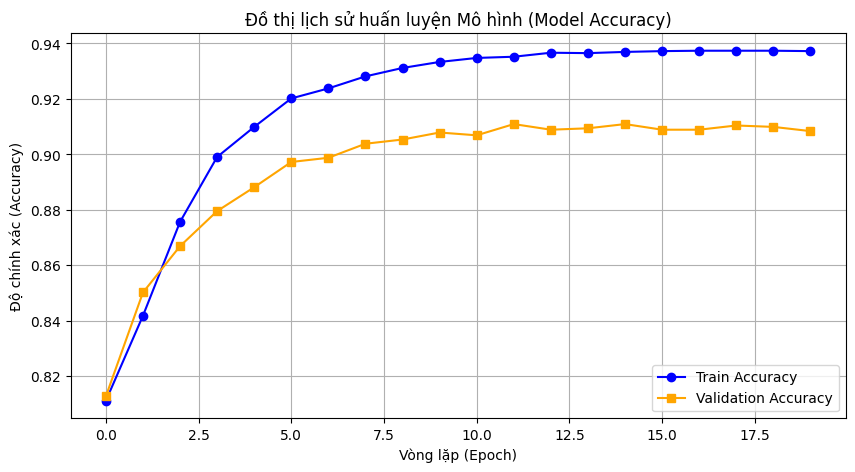

In [11]:
import matplotlib.pyplot as plt

# Vẽ đồ thị cho Độ chính xác (Accuracy)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='s')

# Cấu hình các thông tin hiển thị trên đồ thị
plt.title('Đồ thị lịch sử huấn luyện Mô hình (Model Accuracy)')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Độ chính xác (Accuracy)')
plt.legend(loc='lower right')
plt.grid(True)

# Hiển thị đồ thị ra màn hình
plt.show()

# Thử nghiệm mô hình

In [12]:
# 1. Tự viết một câu đánh giá ngẫu nhiên để thử thách AI của bạn
# (Bạn có thể đổi câu này thành bất kỳ câu tiếng Anh nào bạn muốn để test)
new_review = ["The location of the hotel was okay, but the room itself was terrible. The bed was extremely uncomfortable, everything was covered in dust, and the customer service was totally unacceptable. I will definitely never come back here again."]

# 2. Dùng bộ vectorizer đã học từ trước để dịch câu văn này thành ma trận số
new_review_vectorized = vectorizer.transform(new_review).toarray()

# 3. Đưa vào mô hình để dự đoán xác suất tích cực (Giá trị từ 0 đến 1)
prediction_score = review_model.predict(new_review_vectorized)[0][0]

# 4. Biện luận kết quả: Nếu xác suất > 0.5 thì là Tích cực, ngược lại là Tiêu cực
print("\n--- KẾT QUẢ DỰ ĐOÁN THỰC TẾ ---")
print(f"Câu đánh giá: '{new_review[0]}'")
print(f"Xác suất tích cực mô hình đoán: {prediction_score * 100:.2f}%")

if prediction_score > 0.65:
    print("=> Kết luận của AI: Đây là đánh giá TÍCH CỰC (Khen) 👍")
else:
    print("=> Kết luận của AI: Đây là đánh giá TIÊU CỰC (Chê) 👎")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

--- KẾT QUẢ DỰ ĐOÁN THỰC TẾ ---
Câu đánh giá: 'The location of the hotel was okay, but the room itself was terrible. The bed was extremely uncomfortable, everything was covered in dust, and the customer service was totally unacceptable. I will definitely never come back here again.'
Xác suất tích cực mô hình đoán: 99.49%
=> Kết luận của AI: Đây là đánh giá TÍCH CỰC (Khen) 👍


# Xây dựng mô hình 2 có dùng SMOTE

In [13]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Khởi tạo SMOTE
smote = SMOTE(random_state=42)

# 2. Chỉ áp dụng SMOTE trên tập TRAIN (X_train_vectorized, y_train)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vectorized, y_train)

# 3. Kiểm tra lại sự cân bằng
print("--- SỐ LƯỢNG NHÃN SAU KHI CÂN BẰNG ---")
print(pd.Series(y_train_resampled).value_counts())

--- SỐ LƯỢNG NHÃN SAU KHI CÂN BẰNG ---
Sentiment
1    5516
0    5516
Name: count, dtype: int64


In [14]:
# Khởi tạo mô hình mới (Mô hình 2)
balanced_model = Sequential()
balanced_model.add(Dense(input_dim=784, units=256, kernel_initializer='uniform', activation='relu'))
balanced_model.add(Dropout(rate=0.4)) # Tăng nhẹ dropout để chống học vẹt dữ liệu sinh thêm
balanced_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

balanced_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

balanced_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,217 (786.00 KB)

 Trainable params: 201,217 (786.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import tensorflow as tf

# 1. Cấu hình ModelCheckpoint: Chỉ lưu lại bộ trọng số tốt nhất dựa trên val_loss
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_balanced_model.weights.h5', # Tên tệp lưu trọng số (định dạng Keras mới)
    monitor='val_loss',                         # Theo dõi giá trị loss trên tập Validation
    save_best_only=True,                        # THẦN CHÚ: Chỉ lưu lại cấu hình tốt nhất
    save_weights_only=True,                     # Chỉ lưu trọng số cho nhẹ và nhanh
    mode='min',                                 # Chọn mục tiêu là tìm val_loss nhỏ nhất
    verbose=1                                   # In ra thông báo mỗi khi lưu được mẫu xịn hơn
)

# 2. Huấn luyện trên tập resampled (Thêm tham số callbacks)
history_balanced = balanced_model.fit(
    X_train_resampled,
    y_train_resampled,
    batch_size=64,
    epochs=20,                                  # Vẫn chạy đủ 20 epochs không sợ ngắt giữa chừng
    validation_data=(X_val_vectorized, y_val),
    callbacks=[checkpoint_callback]             # Kích hoạt bộ lưu mô hình tốt nhất
)

# 3. SAU KHI TRAIN XONG: Ép mô hình load lại khoảnh khắc huy hoàng nhất
print("\n--- Đang tải lại bộ trọng số tối ưu nhất vào mô hình ---")
balanced_model.load_weights('best_balanced_model.weights.h5')

Epoch 1/20
165/173 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6572 - loss: 0.6278
Epoch 1: val_loss improved from None to 0.49213, saving model to best_balanced_model.weights.h5

Epoch 1: finished saving model to best_balanced_model.weights.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7224 - loss: 0.5503 - val_accuracy: 0.7196 - val_loss: 0.4921
Epoch 2/20
167/173 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8152 - loss: 0.4053
Epoch 2: val_loss improved from 0.49213 to 0.41487, saving model to best_balanced_model.weights.h5

Epoch 2: finished saving model to best_balanced_model.weights.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8214 - loss: 0.3866 - val_accuracy: 0.7348 - val_loss: 0.4149
Epoch 3/20
172/173 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8472 - loss: 0.3225
Epoch 3: val_loss improved from 0.41487 to 0.36938, saving model to best_balanced_model.weights.h5

Epoch 3: finished saving model to best_balanced_model.weights.h5
173/173 ━━━━━━━━

In [16]:
# Tiến hành chấm điểm mô hình trên tập dữ liệu Test hoàn toàn mới
test_loss, test_accuracy = balanced_model.evaluate(X_test_vectorized, y_test)

print("\n--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
print(f"Độ mất mát trên tập Test (Test Loss): {test_loss:.4f}")
print(f"Độ chính xác trên tập Test (Test Accuracy): {test_accuracy * 100:.2f}%")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7611 - loss: 0.3150

--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
Độ mất mát trên tập Test (Test Loss): 0.3150
Độ chính xác trên tập Test (Test Accuracy): 76.11%


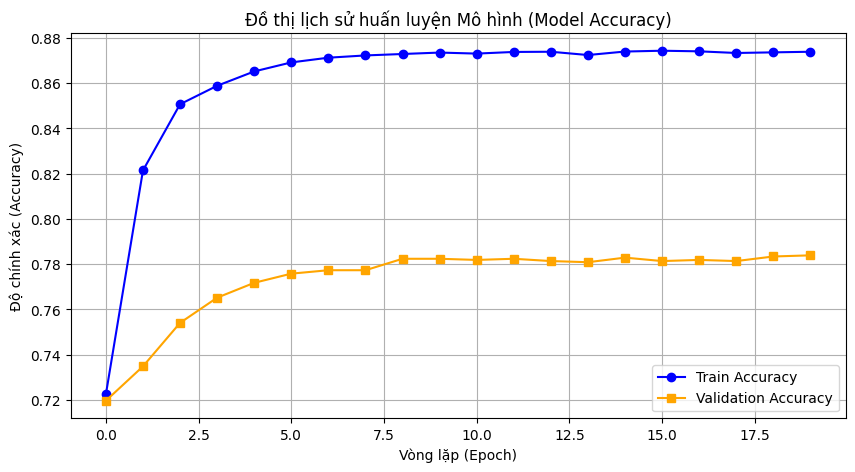

In [17]:
import matplotlib.pyplot as plt

# Vẽ đồ thị cho Độ chính xác (Accuracy)
plt.figure(figsize=(10, 5))
plt.plot(history_balanced.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
plt.plot(history_balanced.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='s')

# Cấu hình các thông tin hiển thị trên đồ thị
plt.title('Đồ thị lịch sử huấn luyện Mô hình (Model Accuracy)')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Độ chính xác (Accuracy)')
plt.legend(loc='lower right')
plt.grid(True)

# Hiển thị đồ thị ra màn hình
plt.show()

In [21]:
# 1. Tự viết một câu đánh giá ngẫu nhiên để thử thách AI của bạn
# (Bạn có thể đổi câu này thành bất kỳ câu tiếng Anh nào bạn muốn để test)
new_review = ["The location of the hotel was okay, but the room itself was terrible. The bed was extremely uncomfortable, everything was covered in dust, and the customer service was totally unacceptable. I will definitely never come back here again."]

# 2.1. SỬA TẠI ĐÂY: Ép câu đánh giá này chạy qua hàm làm sạch clean_text trước!
new_review_cleaned = [clean_text(new_review[0])]

# 2.2. SỬA TẠI ĐÂY: Dịch câu ĐÃ LÀM SẠCH sang ma trận số
new_review_vectorized = vectorizer.transform(new_review_cleaned).toarray()

# 3. Đưa vào mô hình để dự đoán xác suất tích cực (Giá trị từ 0 đến 1)
prediction_score = balanced_model.predict(new_review_vectorized)[0][0]

# 4. Biện luận kết quả: Nếu xác suất > 0.5 thì là Tích cực, ngược lại là Tiêu cực
print("\n--- KẾT QUẢ DỰ ĐOÁN THỰC TẾ ---")
print(f"Câu đánh giá: '{new_review[0]}'")
print(f"Xác suất tích cực mô hình đoán: {prediction_score * 100:.2f}%")

if prediction_score > 0.65:
    print("=> Kết luận của AI: Đây là đánh giá TÍCH CỰC (Khen) 👍")
else:
    print("=> Kết luận của AI: Đây là đánh giá TIÊU CỰC (Chê) 👎")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

--- KẾT QUẢ DỰ ĐOÁN THỰC TẾ ---
Câu đánh giá: 'The location of the hotel was okay, but the room itself was terrible. The bed was extremely uncomfortable, everything was covered in dust, and the customer service was totally unacceptable. I will definitely never come back here again.'
Xác suất tích cực mô hình đoán: 99.12%
=> Kết luận của AI: Đây là đánh giá TÍCH CỰC (Khen) 👍
